In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("D:\projects internship\Gncipl\Project_4\global_ecommerce_sales.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [4]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
std,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593
min,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000


In [6]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [7]:
print("Total Sales:", df["Total_Sales"].sum())

Total Sales: 484559.33999999997


In [8]:
print("Total Profit:", df["Profit"].sum())

Total Profit: 158872.32


In [9]:
region_sales = df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)
print(region_sales)


Region
Europe                  137006.20
North America           133876.38
Asia Pacific            121707.51
South America            46051.13
Middle East & Africa     45918.12
Name: Total_Sales, dtype: float64


In [10]:
top_customers = df.groupby("Customer_Name")["Total_Sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)


Customer_Name
Priya Jackson     3836.46
Hanna Jones       3813.98
Sarah Chen        3184.56
Li Laurent        3007.62
Nadia Wang        2958.97
Priya Oliveira    2901.11
Felix Thompson    2835.36
Linda Weber       2762.40
Karen Sato        2738.18
Lucas Nilsson     2734.69
Name: Total_Sales, dtype: float64


In [12]:
segment_stats = df.groupby("Customer_Segment")[["Discount_Percent", "Quantity"]].mean()
print(segment_stats)


                  Discount_Percent  Quantity
Customer_Segment                            
Consumer                  7.196819  3.580517
Corporate                11.252006  3.523274
Home Office               7.803235  3.552561


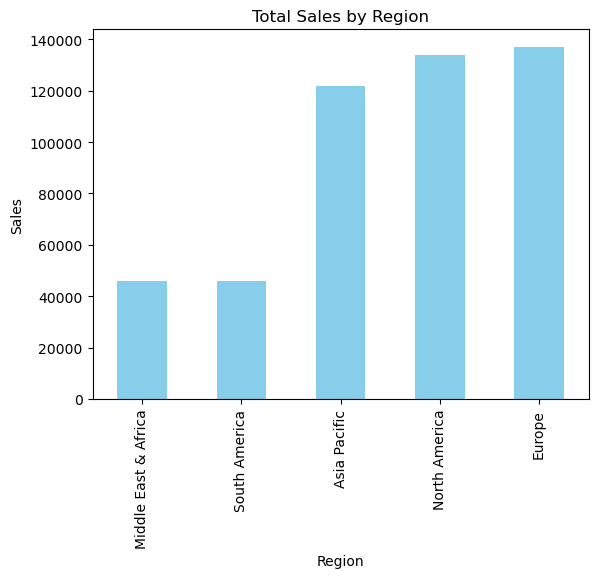

In [16]:

region_sales = df.groupby("Region")["Total_Sales"].sum().sort_values()


region_sales.plot(kind="bar", color="skyblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

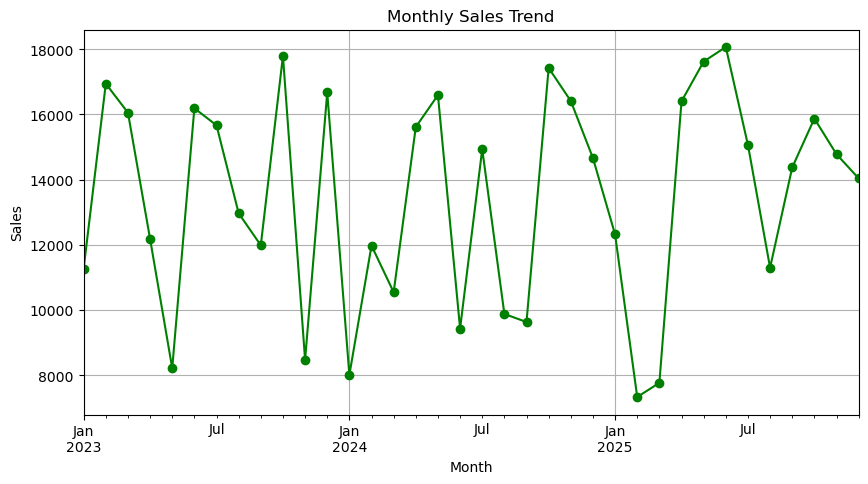

In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o", color="green")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

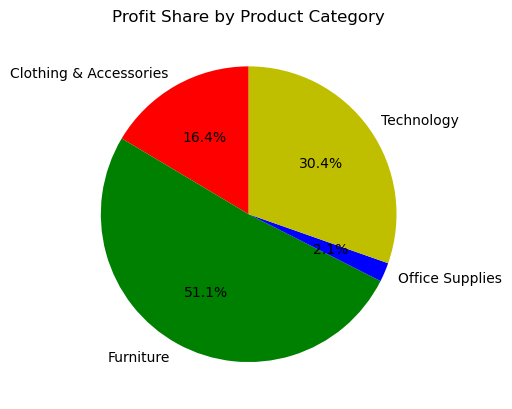

In [21]:
category_profit = df.groupby("Product_Category")["Profit"].sum()


category_profit.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["r","g","b","y"])
plt.title("Profit Share by Product Category")
plt.ylabel("")  
plt.show()


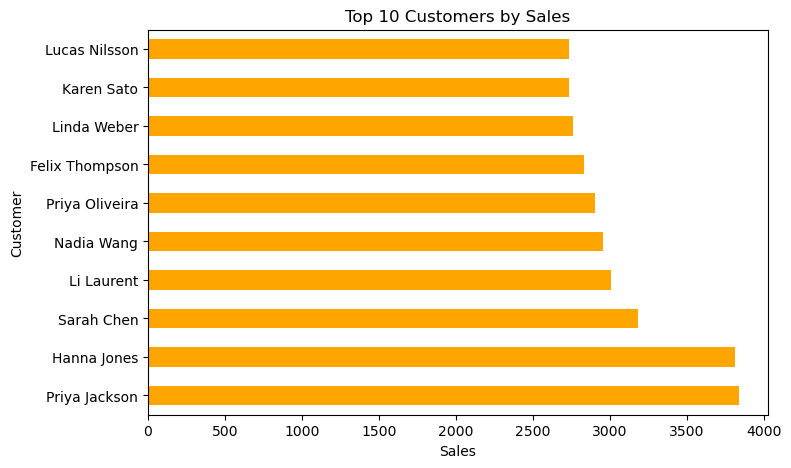

In [23]:
top_customers = df.groupby("Customer_Name")["Total_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_customers.plot(kind="barh", color="orange")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")
plt.show()
